# SC-OTS Ablation: Simplicial vs Random-Matched vs Unconstrained Oblique Tree Splits

This notebook demonstrates the **SC-OTS ablation experiment**, comparing three modes of oblique tree splits:

- **SIMPLICIAL** (Mode A): Uses persistent homology via GUDHI to discover topological feature interactions, constraining oblique splits to simplices from a Rips complex.
- **RANDOM_MATCHED** (Mode B): Generates random feature subsets matching Mode A's cardinality distribution.
- **UNCONSTRAINED** (Mode C): Allows all feature subsets up to size 4.

The experiment uses FIGS-style greedy additive tree sums with SGD-based oblique splits and evaluates with cross-validation.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# dcor, gudhi, loguru — NOT on Colab, always install
_pip('dcor==0.6')
_pip('gudhi==3.10.1')
_pip('loguru==0.7.3')

# numpy, pandas, scikit-learn, scipy, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

In [2]:
from __future__ import annotations

import itertools
import json
import sys
import time
import warnings
from collections import Counter
from dataclasses import dataclass, field
from typing import Optional

import dcor
import gudhi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from loguru import logger
from scipy import stats
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.linear_model import (
    ElasticNet,
    LogisticRegression,
    SGDClassifier,
    SGDRegressor,
)
from sklearn.metrics import accuracy_score, r2_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ── Logging ───────────────────────────────────────────────────────────
GREEN, CYAN, END = "\033[92m", "\033[96m", "\033[0m"
logger.remove()
logger.add(
    sys.stdout,
    level="INFO",
    format=f"{GREEN}{{time:HH:mm:ss}}{END}|{{level:<7}}|{CYAN}{{function}}{END}| {{message}}",
)

1

## Data Loading

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-f5f9f2-simplicial-constrained-oblique-tree-sums/main/experiment_iter3_sc_ots_ablation/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 1 dataset(s)
  friedman1: 100 examples


## Configuration

All tunable parameters for the experiment. Values are set for a quick demo run; original values are commented out.

In [5]:
# ── Experiment Configuration ──────────────────────────────────────
# Full original values (fits within 5-min demo budget with 100 examples)

MAX_TOTAL_SPLITS = 12      # original: 12
MAX_TREES = 4              # original: 4
MAX_DEPTH = 4              # original: 4
MIN_SAMPLES_LEAF = 5       # original: 5
DCOR_SUBSAMPLE = 200       # original: 200
PEARSON_FEATURE_THRESHOLD = 30  # original: 30
MAX_SUBSETS_PER_EVAL = 30  # original: 30
N_RANDOM_SEEDS = 5         # original: 5
N_FOLDS = 5                # original: 5

## Data Structures

Core dataclasses for datasets, oblique splits, tree nodes, and decision trees.

In [6]:
@dataclass
class DatasetInfo:
    name: str
    X: np.ndarray
    y: np.ndarray
    fold_ids: np.ndarray
    task_type: str
    feature_names: list[str]
    known_interactions: Optional[dict] = None
    n_samples: int = 0
    n_features: int = 0

    def __post_init__(self) -> None:
        self.n_samples, self.n_features = self.X.shape


@dataclass
class ObliqueSplit:
    feature_indices: tuple
    weights: np.ndarray
    bias: float
    scaler: Optional[StandardScaler]
    threshold: float
    impurity_decrease: float
    left_mask: np.ndarray
    right_mask: np.ndarray


@dataclass
class TreeNode:
    """Node in a decision tree."""
    is_leaf: bool = True
    value: float = 0.0
    split: Optional[ObliqueSplit] = None
    left: Optional["TreeNode"] = None
    right: Optional["TreeNode"] = None
    sample_indices: Optional[np.ndarray] = None
    depth: int = 0
    n_samples: int = 0


@dataclass
class DecisionTree:
    root: Optional[TreeNode] = None
    n_splits: int = 0

## Phase 0: Data Loading from JSON

Parse the loaded JSON data into `DatasetInfo` objects with feature arrays, fold assignments, and interaction metadata.

In [7]:
def load_datasets(raw: dict) -> dict[str, DatasetInfo]:
    """Load all datasets from the data dict."""
    logger.info(f"Parsing data with {len(raw['datasets'])} datasets")

    datasets: dict[str, DatasetInfo] = {}
    for ds_entry in raw["datasets"]:
        ds_name = ds_entry["dataset"]
        examples = ds_entry["examples"]
        n = len(examples)

        X = np.array([json.loads(ex["input"]) for ex in examples], dtype=np.float64)
        task_type = examples[0]["metadata_task_type"]

        if task_type == "classification":
            y = np.array([int(ex["output"]) for ex in examples], dtype=np.int64)
        else:
            y = np.array([float(ex["output"]) for ex in examples], dtype=np.float64)

        fold_ids = np.array([ex["metadata_fold"] for ex in examples], dtype=np.int64)
        feature_names = examples[0]["metadata_feature_names"]

        # Parse known interactions
        known_interactions = None
        ki_str = examples[0].get("metadata_known_interactions")
        if ki_str:
            known_interactions = json.loads(ki_str)

        ds_info = DatasetInfo(
            name=ds_name,
            X=X,
            y=y,
            fold_ids=fold_ids,
            task_type=task_type,
            feature_names=feature_names,
            known_interactions=known_interactions,
        )
        datasets[ds_name] = ds_info
        logger.info(
            f"  {ds_name}: {n} examples, {X.shape[1]} features, "
            f"task={task_type}, folds={np.unique(fold_ids).tolist()}"
        )

    return datasets

datasets = load_datasets(data)
logger.info(f"Loaded {len(datasets)} datasets")

00:32:12|INFO   |load_datasets| Parsing data with 1 datasets


00:32:12|INFO   |load_datasets|   friedman1: 100 examples, 10 features, task=regression, folds=[0, 1, 2, 3, 4]


00:32:12|INFO   |<module>| Loaded 1 datasets


## Phase 1: Oblique Split Optimizer

Fits oblique (multi-feature) splits using SGD-based linear models. The split is defined by a weight vector and threshold on the projected space.

In [8]:
def compute_impurity(y: np.ndarray, task_type: str) -> float:
    """Compute impurity of a node: variance for regression, Gini for classification."""
    if len(y) == 0:
        return 0.0
    if task_type == "regression":
        return float(np.var(y))
    else:
        classes, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return float(1.0 - np.sum(probs**2))


def compute_impurity_decrease(
    y: np.ndarray,
    left_mask: np.ndarray,
    right_mask: np.ndarray,
    task_type: str,
) -> float:
    """Compute weighted impurity decrease from a split."""
    n = len(y)
    n_left = left_mask.sum()
    n_right = right_mask.sum()
    if n_left == 0 or n_right == 0:
        return 0.0

    parent_impurity = compute_impurity(y, task_type)
    left_impurity = compute_impurity(y[left_mask], task_type)
    right_impurity = compute_impurity(y[right_mask], task_type)

    weighted_child = (n_left / n) * left_impurity + (n_right / n) * right_impurity
    return parent_impurity - weighted_child


def _axis_aligned_fallback(
    X_sub: np.ndarray,
    y: np.ndarray,
    feature_subset: tuple,
    task_type: str,
    min_samples_leaf: int,
    scaler: StandardScaler,
) -> Optional[ObliqueSplit]:
    """Fallback: find best single-feature threshold split."""
    n_features_sub = X_sub.shape[1]
    best_decrease = -1.0
    best_split = None

    for fi in range(n_features_sub):
        col = X_sub[:, fi]
        unique_vals = np.unique(col)
        if len(unique_vals) < 2:
            continue

        try:
            candidates = np.percentile(col, np.arange(10, 100, 10))
        except Exception:
            continue

        for t in candidates:
            left_mask = col <= t
            right_mask = ~left_mask
            if left_mask.sum() < min_samples_leaf or right_mask.sum() < min_samples_leaf:
                continue
            decrease = compute_impurity_decrease(y, left_mask, right_mask, task_type)
            if decrease > best_decrease:
                best_decrease = decrease
                w = np.zeros(n_features_sub)
                w[fi] = 1.0
                best_split = ObliqueSplit(
                    feature_indices=feature_subset,
                    weights=w,
                    bias=0.0,
                    scaler=None,
                    threshold=t,
                    impurity_decrease=decrease,
                    left_mask=left_mask,
                    right_mask=right_mask,
                )

    return best_split


def fit_oblique_split(
    X: np.ndarray,
    y: np.ndarray,
    feature_subset: tuple,
    task_type: str,
    min_samples_leaf: int = MIN_SAMPLES_LEAF,
) -> Optional[ObliqueSplit]:
    """Fit an oblique split on the given feature subset."""
    n_samples = len(y)
    if n_samples < 2 * min_samples_leaf:
        return None

    X_sub = X[:, list(feature_subset)]
    scaler = StandardScaler()

    try:
        X_scaled = scaler.fit_transform(X_sub)
    except ValueError:
        return None

    if np.all(scaler.scale_ < 1e-10):
        return None

    try:
        if task_type == "classification":
            n_classes = len(np.unique(y))
            if n_classes < 2:
                return None
            model = SGDClassifier(
                loss="log_loss",
                penalty="elasticnet",
                l1_ratio=0.85,
                max_iter=100,
                tol=1e-4,
                random_state=42,
            )
            model.fit(X_scaled, y)
            w = model.coef_.flatten()
            b = float(np.asarray(model.intercept_).flatten()[0])
        else:
            model = SGDRegressor(
                loss="squared_error",
                penalty="elasticnet",
                l1_ratio=0.85,
                max_iter=100,
                tol=1e-4,
                random_state=42,
            )
            model.fit(X_scaled, y)
            w = model.coef_.flatten()
            b = float(np.asarray(model.intercept_).flatten()[0])
    except Exception:
        return _axis_aligned_fallback(X_sub, y, feature_subset, task_type, min_samples_leaf, scaler)

    if np.all(np.abs(w) < 1e-10):
        return _axis_aligned_fallback(X_sub, y, feature_subset, task_type, min_samples_leaf, scaler)

    z = X_scaled @ w + b

    try:
        candidates = np.percentile(z, np.arange(10, 100, 10))
    except Exception:
        return None

    best_thresh = None
    best_decrease = -1.0

    for t in candidates:
        left_mask = z <= t
        right_mask = ~left_mask
        n_left = left_mask.sum()
        n_right = right_mask.sum()
        if n_left < min_samples_leaf or n_right < min_samples_leaf:
            continue
        decrease = compute_impurity_decrease(y, left_mask, right_mask, task_type)
        if decrease > best_decrease:
            best_decrease = decrease
            best_thresh = t

    if best_thresh is None or best_decrease <= 0:
        return None

    left_mask = z <= best_thresh
    right_mask = ~left_mask

    return ObliqueSplit(
        feature_indices=feature_subset,
        weights=w,
        bias=b,
        scaler=scaler,
        threshold=best_thresh,
        impurity_decrease=best_decrease,
        left_mask=left_mask,
        right_mask=right_mask,
    )

print("Oblique split optimizer defined.")

Oblique split optimizer defined.


## Phase 2: FIGS-Style Greedy Tree Sum

Greedy additive tree sum model (FIGS-style) that iteratively adds oblique splits to minimize residuals. Each step chooses between splitting an existing leaf or creating a new tree.

In [9]:
class FIGSTreeSum:
    """Greedy additive tree sum (FIGS-style) with oblique splits."""

    def __init__(
        self,
        max_total_splits: int = MAX_TOTAL_SPLITS,
        max_trees: int = MAX_TREES,
        max_depth: int = MAX_DEPTH,
        min_samples_leaf: int = MIN_SAMPLES_LEAF,
    ) -> None:
        self.max_total_splits = max_total_splits
        self.max_trees = max_trees
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.trees_: list[DecisionTree] = []
        self.task_type: str = "regression"
        self._global_mean: float = 0.0

    def _get_total_splits(self) -> int:
        return sum(t.n_splits for t in self.trees_)

    def _predict_tree(self, tree: DecisionTree, X: np.ndarray) -> np.ndarray:
        preds = np.full(X.shape[0], 0.0)
        if tree.root is None:
            return preds
        self._predict_node(tree.root, X, np.arange(X.shape[0]), preds)
        return preds

    def _predict_node(self, node: TreeNode, X: np.ndarray, indices: np.ndarray, preds: np.ndarray) -> None:
        if len(indices) == 0:
            return
        if node.is_leaf:
            preds[indices] = node.value
            return
        split = node.split
        if split is None:
            preds[indices] = node.value
            return
        feat_idx = list(split.feature_indices)
        X_sub = X[np.ix_(indices, feat_idx)]
        if split.scaler is not None:
            X_scaled = split.scaler.transform(X_sub)
            z = X_scaled @ split.weights + split.bias
        else:
            z = X_sub @ split.weights + split.bias
        left_mask = z <= split.threshold
        right_mask = ~left_mask
        self._predict_node(node.left, X, indices[left_mask], preds)
        self._predict_node(node.right, X, indices[right_mask], preds)

    def _compute_residuals(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        total_pred = np.full(len(y), self._global_mean)
        for tree in self.trees_:
            total_pred += self._predict_tree(tree, X)
        return y - total_pred

    def _get_leaves(self, tree: DecisionTree) -> list[TreeNode]:
        if tree.root is None:
            return []
        leaves = []
        self._collect_leaves(tree.root, leaves)
        return leaves

    def _collect_leaves(self, node: TreeNode, leaves: list[TreeNode]) -> None:
        if node.is_leaf:
            leaves.append(node)
        else:
            if node.left:
                self._collect_leaves(node.left, leaves)
            if node.right:
                self._collect_leaves(node.right, leaves)

    def _route_samples(self, node: TreeNode, X: np.ndarray, indices: np.ndarray) -> dict:
        result: dict[int, np.ndarray] = {}
        self._route_recursive(node, X, indices, result)
        return result

    def _route_recursive(self, node: TreeNode, X: np.ndarray, indices: np.ndarray, result: dict) -> None:
        if len(indices) == 0:
            return
        if node.is_leaf:
            result[id(node)] = indices
            return
        split = node.split
        feat_idx = list(split.feature_indices)
        X_sub = X[np.ix_(indices, feat_idx)]
        if split.scaler is not None:
            X_scaled = split.scaler.transform(X_sub)
            z = X_scaled @ split.weights + split.bias
        else:
            z = X_sub @ split.weights + split.bias
        left_mask = z <= split.threshold
        right_mask = ~left_mask
        self._route_recursive(node.left, X, indices[left_mask], result)
        self._route_recursive(node.right, X, indices[right_mask], result)

    def fit(self, X_train, y_train, constraint_source, task_type):
        """Fit the FIGS tree sum model."""
        self.task_type = task_type
        self.trees_ = []

        if task_type == "regression":
            self._global_mean = float(np.mean(y_train))
        else:
            p = np.clip(np.mean(y_train), 0.01, 0.99)
            self._global_mean = float(np.log(p / (1 - p)))

        n_train = len(y_train)

        if n_train > 50:
            try:
                if task_type == "classification":
                    tr_idx, val_idx = train_test_split(np.arange(n_train), test_size=0.1, stratify=y_train, random_state=42)
                else:
                    tr_idx, val_idx = train_test_split(np.arange(n_train), test_size=0.1, random_state=42)
            except ValueError:
                tr_idx, val_idx = train_test_split(np.arange(n_train), test_size=0.1, random_state=42)
            X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
            X_val, y_val = X_train[val_idx], y_train[val_idx]
        else:
            X_tr, y_tr = X_train, y_train
            X_val, y_val = None, None

        no_improvement_count = 0
        best_val_score = -np.inf

        allowed_subsets = constraint_source.get_subsets()
        if len(allowed_subsets) == 0:
            logger.warning("No allowed subsets from constraint source")
            return self

        if len(allowed_subsets) > MAX_SUBSETS_PER_EVAL:
            rng = np.random.RandomState(42)
            subset_indices = rng.choice(len(allowed_subsets), MAX_SUBSETS_PER_EVAL, replace=False)
            eval_subsets = [allowed_subsets[i] for i in subset_indices]
        else:
            eval_subsets = allowed_subsets

        for _step in range(self.max_total_splits):
            if self._get_total_splits() >= self.max_total_splits:
                break
            if len(self.trees_) >= self.max_trees and all(
                len(self._get_leaves(t)) == 0 or all(
                    leaf.depth >= self.max_depth for leaf in self._get_leaves(t)
                )
                for t in self.trees_
            ):
                break

            residuals = self._compute_residuals(X_tr, y_tr)

            if task_type == "classification":
                total_pred = np.full(len(y_tr), self._global_mean)
                for tree in self.trees_:
                    total_pred += self._predict_tree(tree, X_tr)
                probs = 1.0 / (1.0 + np.exp(-total_pred))
                probs = np.clip(probs, 1e-6, 1 - 1e-6)
                residuals = y_tr - probs

            best_overall_split = None
            best_overall_decrease = -1.0
            best_position = None

            for tree_idx, tree in enumerate(self.trees_):
                if tree.root is None:
                    continue
                leaf_samples = self._route_samples(tree.root, X_tr, np.arange(len(X_tr)))
                for leaf in self._get_leaves(tree):
                    if leaf.depth >= self.max_depth:
                        continue
                    leaf_id = id(leaf)
                    if leaf_id not in leaf_samples:
                        continue
                    sample_idx = leaf_samples[leaf_id]
                    if len(sample_idx) < 2 * self.min_samples_leaf:
                        continue
                    X_leaf = X_tr[sample_idx]
                    r_leaf = residuals[sample_idx]
                    for subset in eval_subsets:
                        split = fit_oblique_split(X_leaf, r_leaf, subset, "regression", self.min_samples_leaf)
                        if split is not None and split.impurity_decrease > best_overall_decrease:
                            best_overall_decrease = split.impurity_decrease
                            best_overall_split = split
                            best_position = (tree_idx, leaf)

            if len(self.trees_) < self.max_trees:
                for subset in eval_subsets:
                    split = fit_oblique_split(X_tr, residuals, subset, "regression", self.min_samples_leaf)
                    if split is not None and split.impurity_decrease > best_overall_decrease:
                        best_overall_decrease = split.impurity_decrease
                        best_overall_split = split
                        best_position = ("new", None)

            if best_overall_split is None or best_overall_decrease <= 1e-8:
                break

            split = best_overall_split
            if best_position[0] == "new":
                root = TreeNode(is_leaf=False, depth=0, n_samples=len(X_tr))
                root.split = split
                left_idx = np.where(split.left_mask)[0]
                right_idx = np.where(split.right_mask)[0]
                root.left = TreeNode(is_leaf=True, value=float(np.mean(residuals[left_idx])), depth=1, n_samples=len(left_idx))
                root.right = TreeNode(is_leaf=True, value=float(np.mean(residuals[right_idx])), depth=1, n_samples=len(right_idx))
                new_tree = DecisionTree(root=root, n_splits=1)
                self.trees_.append(new_tree)
            else:
                tree_idx, leaf_node = best_position
                leaf_id = id(leaf_node)
                leaf_samples_map = self._route_samples(self.trees_[tree_idx].root, X_tr, np.arange(len(X_tr)))
                sample_idx = leaf_samples_map.get(leaf_id, np.array([], dtype=int))
                leaf_node.is_leaf = False
                leaf_node.split = split
                left_idx = sample_idx[split.left_mask]
                right_idx = sample_idx[split.right_mask]
                leaf_node.left = TreeNode(is_leaf=True, value=float(np.mean(residuals[left_idx])) if len(left_idx) > 0 else 0.0, depth=leaf_node.depth + 1, n_samples=len(left_idx))
                leaf_node.right = TreeNode(is_leaf=True, value=float(np.mean(residuals[right_idx])) if len(right_idx) > 0 else 0.0, depth=leaf_node.depth + 1, n_samples=len(right_idx))
                self.trees_[tree_idx].n_splits += 1

            if X_val is not None:
                val_score = self._evaluate_score(X_val, y_val)
                if val_score > best_val_score:
                    best_val_score = val_score
                    no_improvement_count = 0
                else:
                    no_improvement_count += 1
                if no_improvement_count >= 3:
                    break

        return self

    def predict_raw(self, X: np.ndarray) -> np.ndarray:
        preds = np.full(X.shape[0], self._global_mean)
        for tree in self.trees_:
            preds += self._predict_tree(tree, X)
        return preds

    def predict(self, X: np.ndarray) -> np.ndarray:
        raw = self.predict_raw(X)
        if self.task_type == "classification":
            probs = 1.0 / (1.0 + np.exp(-raw))
            return (probs >= 0.5).astype(int)
        return raw

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        raw = self.predict_raw(X)
        probs = 1.0 / (1.0 + np.exp(-raw))
        return np.clip(probs, 0.0, 1.0)

    def _evaluate_score(self, X: np.ndarray, y: np.ndarray) -> float:
        if self.task_type == "classification":
            try:
                probs = self.predict_proba(X)
                return float(roc_auc_score(y, probs))
            except ValueError:
                preds = self.predict(X)
                return float(accuracy_score(y, preds))
        else:
            preds = self.predict_raw(X)
            return float(r2_score(y, preds))

print("FIGSTreeSum model defined.")

FIGSTreeSum model defined.


## Phase 3: Constraint Sources

Three constraint modes for generating feature subsets:
- **SimplicialConstraintSource**: TDA pipeline using dCor distance, GUDHI Rips complex, persistent homology, and MI filtering.
- **RandomMatchedConstraintSource**: Random subsets matching the simplicial source's cardinality distribution.
- **UnconstrainedConstraintSource**: All feature subsets up to size 4.

In [10]:
class ConstraintSource:
    """Base class for constraint sources."""
    def __init__(self) -> None:
        self.allowed_subsets: list[tuple] = []

    def get_subsets(self) -> list[tuple]:
        return self.allowed_subsets


class SimplicialConstraintSource(ConstraintSource):
    """TDA pipeline: dCor -> GUDHI Rips -> persistence -> simplices -> MI filter."""

    def __init__(self) -> None:
        super().__init__()
        self.threshold: float = 0.0
        self.betti_numbers: list[int] = [0, 0, 0]
        self.n_simplices_by_dim: dict[str, int] = {}

    def build(self, X_train, y_train, task_type, feature_names):
        """Build simplicial complex from training data."""
        n_features = X_train.shape[1]

        # Step 1: Distance matrix
        if n_features > PEARSON_FEATURE_THRESHOLD:
            D = self._compute_pearson_distance(X_train)
        else:
            D = self._compute_dcor_distance(X_train)

        # Step 2: Target-aware MI weighting
        try:
            if task_type == "classification":
                mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
            else:
                mi_scores = mutual_info_regression(X_train, y_train, random_state=42)

            epsilon = 0.01
            D_weighted = D.copy()
            for i in range(n_features):
                for j in range(i + 1, n_features):
                    weight = np.sqrt(mi_scores[i] * mi_scores[j]) + epsilon
                    D_weighted[i, j] /= weight
                    D_weighted[j, i] /= weight
        except Exception:
            D_weighted = D.copy()
            mi_scores = np.ones(n_features)

        # Step 3: Build GUDHI Rips complex
        try:
            max_edge = float(np.max(D_weighted[D_weighted < np.inf]))
            if max_edge <= 0 or not np.isfinite(max_edge):
                max_edge = 2.0
            np.fill_diagonal(D_weighted, 0.0)
            rips = gudhi.RipsComplex(distance_matrix=D_weighted.tolist(), max_edge_length=max_edge)
            max_dim = min(3, n_features - 1)
            st = rips.create_simplex_tree(max_dimension=max_dim)
        except Exception:
            logger.exception("GUDHI Rips construction failed")
            return self._fallback_mi_pairs(mi_scores, n_features)

        # Step 4: Persistence and threshold
        try:
            persistence = st.persistence()
            threshold = self._select_persistence_threshold(st, persistence)
            self.threshold = threshold
        except Exception:
            threshold = max_edge * 0.75
            self.threshold = threshold

        # Step 5: Extract persistent simplices
        simplices = []
        for simplex, filt_value in st.get_filtration():
            if filt_value <= threshold and len(simplex) >= 2:
                simplices.append(tuple(sorted(simplex)))
        simplices = list(set(simplices))

        # Step 6: MI-based filtering
        if len(mi_scores) > 0:
            mi_threshold = np.percentile(mi_scores, 25)
            filtered = [s for s in simplices if all(mi_scores[f] >= mi_threshold for f in s if f < len(mi_scores))]
            if len(filtered) >= 3:
                simplices = filtered

        if len(simplices) > 500:
            scored = [(np.mean([mi_scores[f] for f in s if f < len(mi_scores)]), s) for s in simplices]
            scored.sort(reverse=True)
            simplices = [s for _, s in scored[:200]]

        # Step 7: Safety net
        simplices = self._safety_net(simplices, mi_scores, n_features)
        self.allowed_subsets = simplices
        self._compute_complex_info(simplices, st)
        logger.debug(f"Simplicial complex: {len(simplices)} simplices, dims={self.n_simplices_by_dim}")
        return self

    def _compute_dcor_distance(self, X):
        n_features = X.shape[1]
        n_sub = min(X.shape[0], DCOR_SUBSAMPLE)
        rng = np.random.RandomState(42)
        idx = rng.choice(X.shape[0], n_sub, replace=False)
        X_sub = X[idx]
        dcor_matrix = np.ones((n_features, n_features))
        for i in range(n_features):
            for j in range(i + 1, n_features):
                try:
                    dc = dcor.distance_correlation(X_sub[:, i], X_sub[:, j])
                    if not np.isfinite(dc):
                        dc = 0.0
                    dcor_matrix[i, j] = dc
                    dcor_matrix[j, i] = dc
                except Exception:
                    dcor_matrix[i, j] = 0.0
                    dcor_matrix[j, i] = 0.0
        D = np.sqrt(np.clip(1.0 - dcor_matrix, 0.0, 1.0))
        np.fill_diagonal(D, 0.0)
        return D

    def _compute_pearson_distance(self, X):
        n_sub = min(X.shape[0], 500)
        rng = np.random.RandomState(42)
        idx = rng.choice(X.shape[0], n_sub, replace=False)
        X_sub = X[idx]
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            corr = np.corrcoef(X_sub.T)
        corr = np.nan_to_num(corr, nan=0.0)
        D = 1.0 - np.abs(corr)
        np.fill_diagonal(D, 0.0)
        D = np.clip(D, 0.0, 2.0)
        return D

    def _select_persistence_threshold(self, st, persistence):
        death_values = [death for dim, (birth, death) in persistence if np.isfinite(death) and death > 0]
        if len(death_values) < 2:
            filt_values = [fv for _, fv in st.get_filtration() if fv > 0]
            if filt_values:
                return float(np.percentile(filt_values, 75))
            return 1.0
        death_values.sort()
        gaps = np.diff(death_values)
        if len(gaps) == 0:
            return float(death_values[-1])
        largest_gap_idx = np.argmax(gaps)
        threshold = (death_values[largest_gap_idx] + death_values[largest_gap_idx + 1]) / 2.0
        return float(threshold)

    def _safety_net(self, simplices, mi_scores, n_features):
        if len(simplices) >= max(3, n_features // 2):
            return simplices
        ranked = np.argsort(mi_scores)[::-1]
        top_features = ranked[: max(n_features // 2, 3)]
        additional = []
        for i in range(len(top_features)):
            for j in range(i + 1, len(top_features)):
                pair = tuple(sorted([int(top_features[i]), int(top_features[j])]))
                if pair not in simplices and pair not in additional:
                    additional.append(pair)
        return simplices + additional

    def _fallback_mi_pairs(self, mi_scores, n_features):
        ranked = np.argsort(mi_scores)[::-1]
        top_k = max(n_features // 2, 3)
        top_features = ranked[:top_k]
        simplices = []
        for i in range(len(top_features)):
            for j in range(i + 1, len(top_features)):
                simplices.append(tuple(sorted([int(top_features[i]), int(top_features[j])])))
        self.allowed_subsets = simplices
        self.threshold = 0.0
        self.betti_numbers = [0, 0, 0]
        self.n_simplices_by_dim = {"1": len(simplices)}
        return self

    def _compute_complex_info(self, simplices, st):
        dim_counts: dict[str, int] = {}
        for s in simplices:
            dim = str(len(s) - 1)
            dim_counts[dim] = dim_counts.get(dim, 0) + 1
        self.n_simplices_by_dim = dim_counts
        try:
            betti = st.betti_numbers()
            self.betti_numbers = list(betti[:3]) if len(betti) >= 3 else list(betti) + [0] * (3 - len(betti))
        except Exception:
            self.betti_numbers = [0, 0, 0]


class RandomMatchedConstraintSource(ConstraintSource):
    """Generate random feature subsets matching Mode A's cardinality distribution."""

    def build(self, simplicial_source, n_features, seed):
        cardinality_dist = Counter(len(s) for s in simplicial_source.allowed_subsets)
        rng = np.random.RandomState(seed)
        subsets = []
        for size, count in cardinality_dist.items():
            if size > n_features:
                size = min(size, n_features)
            for _ in range(count):
                subset = tuple(sorted(rng.choice(n_features, size=size, replace=False)))
                subsets.append(subset)
        covered = set(f for s in subsets for f in s)
        uncovered = set(range(n_features)) - covered
        for f in uncovered:
            partner = rng.randint(0, n_features)
            while partner == f:
                partner = rng.randint(0, n_features)
            subsets.append(tuple(sorted([f, partner])))
        self.allowed_subsets = list(set(subsets))
        return self


class UnconstrainedConstraintSource(ConstraintSource):
    """All feature subsets up to size 4."""

    def build(self, n_features, max_size=4, max_candidates=200):
        all_subsets = []
        actual_max_size = min(max_size, n_features)
        for k in range(2, actual_max_size + 1):
            all_subsets.extend(itertools.combinations(range(n_features), k))
        if len(all_subsets) > max_candidates:
            rng = np.random.RandomState(42)
            indices = rng.choice(len(all_subsets), max_candidates, replace=False)
            self.allowed_subsets = [tuple(all_subsets[i]) for i in indices]
        else:
            self.allowed_subsets = [tuple(s) for s in all_subsets]
        return self

print("Constraint sources defined.")

Constraint sources defined.


## Phase 4: Evaluation Metrics

Model evaluation functions: R^2 for regression, AUC-ROC/accuracy for classification, and interaction recovery metrics.

In [11]:
def evaluate_model(model, X_test, y_test, task_type):
    """Evaluate model score."""
    if task_type == "classification":
        try:
            probs = model.predict_proba(X_test)
            return float(roc_auc_score(y_test, probs))
        except ValueError:
            preds = model.predict(X_test)
            return float(accuracy_score(y_test, preds))
    else:
        preds = model.predict_raw(X_test)
        return float(r2_score(y_test, preds))


def get_model_predictions(model, X_test, task_type):
    """Get predictions for output."""
    if task_type == "classification":
        return model.predict_proba(X_test)
    else:
        return model.predict_raw(X_test)


def compute_interaction_recovery(allowed_subsets, known_interactions):
    """Compute precision/recall/F1 for interaction recovery."""
    known_set = set()
    for key in ["2-way", "3-way", "4-way"]:
        if key in known_interactions:
            for interaction in known_interactions[key]:
                known_set.add(tuple(sorted(interaction)))
    if len(known_set) == 0:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0}
    predicted_set = set(tuple(sorted(s)) for s in allowed_subsets)
    tp = len(predicted_set & known_set)
    precision = tp / len(predicted_set) if len(predicted_set) > 0 else 0.0
    recall = tp / len(known_set) if len(known_set) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"precision": precision, "recall": recall, "f1": f1}

print("Evaluation functions defined.")

Evaluation functions defined.


## Phase 5: Main Experiment Loop

Run the ablation across all datasets and folds, comparing three constraint modes (SIMPLICIAL, RANDOM_MATCHED, UNCONSTRAINED).

In [12]:
def run_experiment(datasets, max_folds=None):
    """Run the full ablation experiment."""
    results = {}
    predictions = {}
    n_folds_to_run = max_folds if max_folds is not None else N_FOLDS

    total_start = time.time()

    for ds_idx, (ds_name, ds) in enumerate(datasets.items()):
        logger.info(f"=== Dataset {ds_idx+1}/{len(datasets)}: {ds_name} "
                     f"(n={ds.n_samples}, p={ds.n_features}, task={ds.task_type}) ===")

        results[ds_name] = {
            "task_type": ds.task_type,
            "n_samples": ds.n_samples,
            "n_features": ds.n_features,
            "folds": {},
        }
        predictions[ds_name] = {}

        # Determine which folds to use
        unique_folds = sorted(np.unique(ds.fold_ids))
        folds_to_run = unique_folds[:n_folds_to_run]

        for fold in folds_to_run:
            fold_start = time.time()
            logger.info(f"  Fold {fold}/{len(folds_to_run)-1}")

            train_mask = ds.fold_ids != fold
            test_mask = ds.fold_ids == fold

            X_train, y_train = ds.X[train_mask], ds.y[train_mask]
            X_test, y_test = ds.X[test_mask], ds.y[test_mask]
            test_indices = np.where(test_mask)[0]

            scaler = StandardScaler()
            X_train_s = scaler.fit_transform(X_train)
            X_test_s = scaler.transform(X_test)

            fold_results = {}

            # ── MODE A: SIMPLICIAL ──
            try:
                simp_src = SimplicialConstraintSource()
                simp_src.build(X_train=X_train_s, y_train=y_train, task_type=ds.task_type, feature_names=ds.feature_names)

                model_A = FIGSTreeSum(max_total_splits=MAX_TOTAL_SPLITS, max_trees=MAX_TREES, max_depth=MAX_DEPTH, min_samples_leaf=MIN_SAMPLES_LEAF)
                t0 = time.time()
                model_A.fit(X_train_s, y_train, simp_src, ds.task_type)
                time_A = time.time() - t0

                score_A = evaluate_model(model_A, X_test_s, y_test, ds.task_type)
                splits_A = model_A._get_total_splits()
                preds_A = get_model_predictions(model_A, X_test_s, ds.task_type)

                fold_results["SIMPLICIAL"] = {"score": round(score_A, 6), "splits": splits_A, "time_s": round(time_A, 3)}
                logger.info(f"    Mode A (SIMPLICIAL): score={score_A:.4f}, splits={splits_A}, time={time_A:.1f}s")
            except Exception:
                logger.exception(f"    Mode A failed on {ds_name} fold {fold}")
                fold_results["SIMPLICIAL"] = {"score": 0.0, "splits": 0, "time_s": 0.0}
                preds_A = np.zeros(len(y_test))
                simp_src = SimplicialConstraintSource()
                simp_src.allowed_subsets = [(0, 1)]

            # ── MODE B: RANDOM-MATCHED ──
            scores_B, splits_B_list, times_B, preds_B_all = [], [], [], []
            for seed in range(N_RANDOM_SEEDS):
                try:
                    rand_src = RandomMatchedConstraintSource()
                    rand_src.build(simp_src, ds.n_features, seed)
                    model_B = FIGSTreeSum(max_total_splits=MAX_TOTAL_SPLITS, max_trees=MAX_TREES, max_depth=MAX_DEPTH, min_samples_leaf=MIN_SAMPLES_LEAF)
                    t0 = time.time()
                    model_B.fit(X_train_s, y_train, rand_src, ds.task_type)
                    t_B = time.time() - t0
                    s_B = evaluate_model(model_B, X_test_s, y_test, ds.task_type)
                    sp_B = model_B._get_total_splits()
                    p_B = get_model_predictions(model_B, X_test_s, ds.task_type)
                    scores_B.append(s_B); splits_B_list.append(sp_B); times_B.append(t_B); preds_B_all.append(p_B)
                except Exception:
                    logger.exception(f"    Mode B seed {seed} failed")
                    scores_B.append(0.0); splits_B_list.append(0); times_B.append(0.0)
                    preds_B_all.append(np.zeros(len(y_test)))

            score_B_mean = float(np.mean(scores_B))
            preds_B = np.mean(preds_B_all, axis=0) if preds_B_all else np.zeros(len(y_test))
            fold_results["RANDOM_MATCHED"] = {"score": round(score_B_mean, 6), "splits": round(float(np.mean(splits_B_list)), 1), "time_s": round(float(np.mean(times_B)), 3)}
            logger.info(f"    Mode B (RANDOM_MATCHED): score={score_B_mean:.4f}")

            # ── MODE C: UNCONSTRAINED ──
            try:
                uncon_src = UnconstrainedConstraintSource()
                uncon_src.build(ds.n_features)
                model_C = FIGSTreeSum(max_total_splits=MAX_TOTAL_SPLITS, max_trees=MAX_TREES, max_depth=MAX_DEPTH, min_samples_leaf=MIN_SAMPLES_LEAF)
                t0 = time.time()
                model_C.fit(X_train_s, y_train, uncon_src, ds.task_type)
                time_C = time.time() - t0
                score_C = evaluate_model(model_C, X_test_s, y_test, ds.task_type)
                splits_C = model_C._get_total_splits()
                preds_C = get_model_predictions(model_C, X_test_s, ds.task_type)
                fold_results["UNCONSTRAINED"] = {"score": round(score_C, 6), "splits": splits_C, "time_s": round(time_C, 3)}
                logger.info(f"    Mode C (UNCONSTRAINED): score={score_C:.4f}, splits={splits_C}")
            except Exception:
                logger.exception(f"    Mode C failed")
                fold_results["UNCONSTRAINED"] = {"score": 0.0, "splits": 0, "time_s": 0.0}
                preds_C = np.zeros(len(y_test))

            # Interaction recovery
            if ds.known_interactions is not None:
                try:
                    fold_results["interaction_recovery"] = {k: round(v, 4) for k, v in compute_interaction_recovery(simp_src.allowed_subsets, ds.known_interactions).items()}
                except Exception:
                    fold_results["interaction_recovery"] = None
            else:
                fold_results["interaction_recovery"] = None

            fold_results["simplicial_complex_info"] = {
                "n_simplices_by_dim": simp_src.n_simplices_by_dim,
                "betti_numbers": simp_src.betti_numbers,
                "persistence_threshold": round(simp_src.threshold, 6),
            }

            results[ds_name]["folds"][str(fold)] = fold_results

            for local_i, global_i in enumerate(test_indices):
                predictions[ds_name][int(global_i)] = {
                    "SIMPLICIAL": float(preds_A[local_i]),
                    "RANDOM_MATCHED": float(preds_B[local_i]),
                    "UNCONSTRAINED": float(preds_C[local_i]),
                }

            logger.info(f"  Fold {fold} completed in {time.time()-fold_start:.1f}s")

        # Per-dataset aggregation
        _aggregate_dataset(results[ds_name], len(folds_to_run))

    total_time = time.time() - total_start
    logger.info(f"Total experiment time: {total_time:.1f}s")
    return results, predictions


def _aggregate_dataset(ds_results, n_folds):
    """Compute per-dataset mean scores, splits, times."""
    modes = ["SIMPLICIAL", "RANDOM_MATCHED", "UNCONSTRAINED"]
    mean_scores, mean_splits, mean_times = {}, {}, {}
    for mode in modes:
        scores, splits, times = [], [], []
        for fold_key in ds_results["folds"]:
            fold_data = ds_results["folds"][fold_key]
            if mode in fold_data:
                scores.append(fold_data[mode]["score"])
                sp = fold_data[mode]["splits"]
                splits.append(float(sp) if isinstance(sp, (int, float)) else 0.0)
                times.append(fold_data[mode]["time_s"])
        mean_scores[mode] = round(float(np.mean(scores)) if scores else 0.0, 6)
        mean_splits[mode] = round(float(np.mean(splits)) if splits else 0.0, 1)
        mean_times[mode] = round(float(np.mean(times)) if times else 0.0, 3)
    ds_results["mean_scores"] = mean_scores
    ds_results["mean_splits"] = mean_splits
    ds_results["mean_time_s"] = mean_times

print("Experiment loop defined.")

Experiment loop defined.


## Run the Experiment

Execute the ablation comparing SIMPLICIAL vs RANDOM_MATCHED vs UNCONSTRAINED oblique splits.

In [13]:
results, predictions = run_experiment(datasets, max_folds=N_FOLDS)
logger.info("Experiment complete!")

00:32:12|INFO   |run_experiment| === Dataset 1/1: friedman1 (n=100, p=10, task=regression) ===


00:32:12|INFO   |run_experiment|   Fold 0/4


00:32:15|INFO   |run_experiment|     Mode A (SIMPLICIAL): score=0.7390, splits=7, time=3.0s


00:32:31|INFO   |run_experiment|     Mode B (RANDOM_MATCHED): score=0.6013


00:32:33|INFO   |run_experiment|     Mode C (UNCONSTRAINED): score=0.3494, splits=7


...

00:34:03|INFO   |run_experiment|     Mode B (RANDOM_MATCHED): score=0.5282


00:34:07|INFO   |run_experiment|     Mode C (UNCONSTRAINED): score=0.4299, splits=6


00:34:07|INFO   |run_experiment|   Fold 4 completed in 27.9s


00:34:07|INFO   |run_experiment| Total experiment time: 114.4s


00:34:07|INFO   |<module>| Experiment complete!


## Results & Visualization

Print summary results and visualize the comparison of three constraint modes across datasets.


RESULTS SUMMARY
  Dataset  SIMPL  RANDO  UNCON
friedman1 0.6131 0.4796 0.4356

--- Aggregate Mean Scores ---
  SIMPLICIAL          : 0.6131 +/- 0.0000
  RANDOM_MATCHED      : 0.4796 +/- 0.0000
  UNCONSTRAINED       : 0.4356 +/- 0.0000


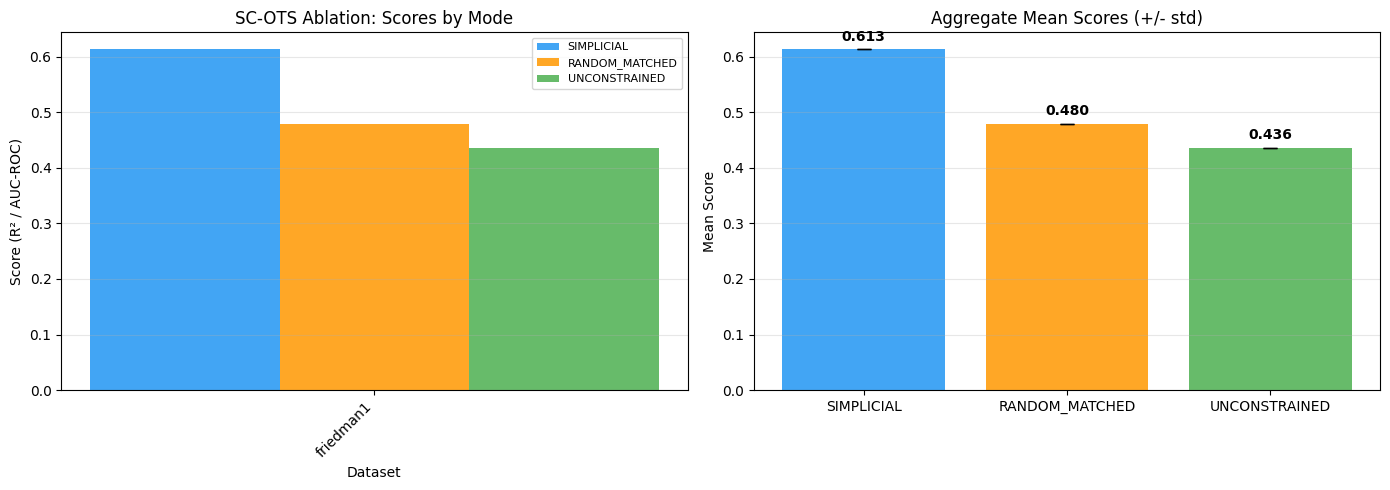


Plot saved to sc_ots_ablation_results.png


In [14]:
# ── Summary Table ──
modes = ["SIMPLICIAL", "RANDOM_MATCHED", "UNCONSTRAINED"]
print("\n" + "=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

rows = []
for ds_name, ds_data in results.items():
    ms = ds_data.get("mean_scores", {})
    row = {"Dataset": ds_name}
    for mode in modes:
        row[mode[:5]] = f"{ms.get(mode, 0.0):.4f}"
    rows.append(row)

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

# Aggregate
print("\n--- Aggregate Mean Scores ---")
for mode in modes:
    scores_list = [results[ds].get("mean_scores", {}).get(mode, 0.0) for ds in results]
    print(f"  {mode:20s}: {np.mean(scores_list):.4f} +/- {np.std(scores_list):.4f}")

# ── Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scores per dataset
ds_names = list(results.keys())
x = np.arange(len(ds_names))
width = 0.25
colors = ['#2196F3', '#FF9800', '#4CAF50']

for i, mode in enumerate(modes):
    scores = [results[ds].get("mean_scores", {}).get(mode, 0.0) for ds in ds_names]
    axes[0].bar(x + i * width, scores, width, label=mode, color=colors[i], alpha=0.85)

axes[0].set_xlabel("Dataset")
axes[0].set_ylabel("Score (R² / AUC-ROC)")
axes[0].set_title("SC-OTS Ablation: Scores by Mode")
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(ds_names, rotation=45, ha='right')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Aggregate comparison
agg_scores = [np.mean([results[ds].get("mean_scores", {}).get(m, 0.0) for ds in ds_names]) for m in modes]
agg_stds = [np.std([results[ds].get("mean_scores", {}).get(m, 0.0) for ds in ds_names]) for m in modes]
bars = axes[1].bar(modes, agg_scores, yerr=agg_stds, color=colors, alpha=0.85, capsize=5)
axes[1].set_ylabel("Mean Score")
axes[1].set_title("Aggregate Mean Scores (+/- std)")
axes[1].grid(axis='y', alpha=0.3)
for bar, score in zip(bars, agg_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("sc_ots_ablation_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved to sc_ots_ablation_results.png")